In [1]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.covariance import MinCovDet
from sklearn.neighbors import KernelDensity
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors # Added NearestNeighbors

In [2]:
SEED = 42
PLOT_DPI = 100

DATA_FILE = "../../datasets/Skoltech_Anomaly_Benchmark/preprocessed_skab_dataset_set2.csv"

In [3]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695,0.0,No Anomaly


In [4]:
dataframe_data = dataframe.drop(columns=["anomaly", "description"])
dataframe_data

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.710228,0.000033,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695


In [5]:
dataframe_no_anomaly = dataframe[dataframe["anomaly"] == 0]
dataframe_no_anomaly.drop(columns=["anomaly", "description"], inplace=True)
dataframe_no_anomaly

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,AccelerometerRMS_Fluctuation,Temperature_Fluctuation,Thermocouple_Fluctuation,Volume Flow RateRMS_Fluctuation,Hydraulic_Power_Fluctuation,Electrical_Power_Fluctuation
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,0.735566,0.000454,0.205773,0.010205,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,0.731142,0.000461,0.225304,0.005911,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,0.732637,0.000459,0.189188,0.009251,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,0.732090,0.000465,0.174736,0.006552,0.000339,0.065560,0.004268,0.239280,42.844684,64.762931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000008,0.051296,0.003156,0.375264,7.244167,28.685529
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,0.704309,0.000032,0.359255,0.006671,0.000005,0.044208,0.003212,0.377068,6.761665,31.409359
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,0.710228,0.000033,0.596906,0.010753,0.000009,0.048716,0.002828,0.377068,5.340617,34.363695


## 1. Parametric Methods (Assumption of Distribution)

You've chosen three fundamental statistical methods for anomaly detection\! I'll implement these as functions within the `src/models.py` module.

Given that these are primarily unsupervised methods (they learn from the data itself, not from labels), their "training" phase involves fitting the underlying distribution or statistics to the `X_train` data. The "prediction" phase then involves calculating anomaly scores (and deriving binary labels) on both `X_train` (for sanity checks or thresholds) and `X_test` (for final evaluation).

For the output labels, I'll use `1` for an anomaly and `0` for normal, which is standard for binary anomaly detection. Since you have multi-class anomalies, these methods will flag any deviation from the "normal" distribution, irrespective of *which* anomaly class it belongs to. The evaluation functions later will compare these binary anomaly predictions against your true multi-class labels, treating any non-normal label as an anomaly.

Here's the plan for each method:

1.  **Z-score / Standard Deviation Method:**

      * **Univariate:** This is inherently a univariate method. To apply it to a multivariate dataset, we'll calculate Z-scores for *each feature independently* and then combine them. A common way to combine is to flag a point as an anomaly if *any* of its features' Z-scores exceed the threshold.
      * **Fitting:** Calculate mean and standard deviation for each feature from `X_train`.
      * **Prediction:** Calculate Z-score for each feature for `X_train` and `X_test`. If any feature's Z-score exceeds a threshold, classify as anomaly.

2.  **Modified Z-score Method:**

      * **Univariate:** Similar to Z-score, also inherently univariate. We'll apply it per feature.
      * **Fitting:** Calculate median and Median Absolute Deviation (MAD) for each feature from `X_train`.
      * **Prediction:** Calculate Modified Z-score for each feature for `X_train` and `X_test`. If any feature's Modified Z-score exceeds a threshold, classify as anomaly.

3.  **Multivariate Gaussian Model:**

      * **Multivariate:** This method directly handles multiple features by modeling their joint probability distribution.
      * **Fitting:** Calculate the mean vector and covariance matrix from `X_train`.
      * **Prediction:** For each data point in `X_train` and `X_test`, calculate its probability density under the learned multivariate Gaussian distribution. Points with a probability density below a certain threshold (or equivalently, an anomaly score above a threshold, as score is usually inversely related to probability) are anomalies. I'll use the negative log-likelihood as an anomaly score (higher score = more anomalous).

### Z-Score / Standard Deviation Method

In [6]:
# --- 1. Z-score / Standard Deviation Method ---
def train_evaluate_zscore(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    threshold: float = 3.0, # Z-score threshold, common values are 2, 3, 3.5
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Implements Z-score method for anomaly detection.
    Fits means and stds on X_train, then predicts on X_train and X_test.
    A data point is an anomaly if any of its feature's absolute Z-score exceeds the threshold.

    Args:
        X_train (pd.DataFrame): Training feature set.
        X_test (pd.DataFrame): Test feature set.
        threshold (float): Z-score threshold for direct labeling.

    Returns:
        tuple: (train_scores, train_labels, test_scores, test_labels)
    """
    print(f"  Training Z-score model with threshold={threshold}...")

    # Fit: Calculate mean and std for each feature on X_train
    means = X_train.mean(axis=0)
    stds = X_train.std(axis=0)

    # Handle cases where std is zero (constant feature) to avoid division by zero
    stds[stds == 0] = 1e-9 # Replace zero std with a small number

    def _calculate_zscores_and_labels(X_data: pd.DataFrame, means: pd.Series, stds: pd.Series):
        z_scores = np.abs((X_data - means) / stds)
        # Anomaly score: Max Z-score across features for each data point
        # Higher score = more anomalous
        scores = z_scores.max(axis=1).values
        # Binary labels based on threshold: 1 if any feature's Z-score > threshold
        labels = (z_scores.max(axis=1) > threshold).astype(int)
        return scores, labels

    # Predict on test set
    test_scores, test_labels = _calculate_zscores_and_labels(X_test, means, stds)

    # Optionally, apply contamination for score-based labels if needed
    # For Z-score, the direct threshold is often preferred, but we can also provide
    # labels based on contamination for consistency with other methods.
    # Let's provide scores and let _convert_scores_to_labels be used in evaluation if desired.
    # For this specific method, the 'labels' derived from 'threshold' are more direct.
    # We will still return the scores for plotting.

    print(f"  Z-score model trained. Detected {np.sum(test_labels)} anomalies in test set (direct threshold).")
    return test_scores, test_labels

In [7]:
_, labels = train_evaluate_zscore(dataframe_no_anomaly, dataframe_data, threshold=3.0)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training Z-score model with threshold=3.0...
  Z-score model trained. Detected 6890 anomalies in test set (direct threshold).


anomaly
0    42312
1     6890
Name: count, dtype: int64

In [8]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

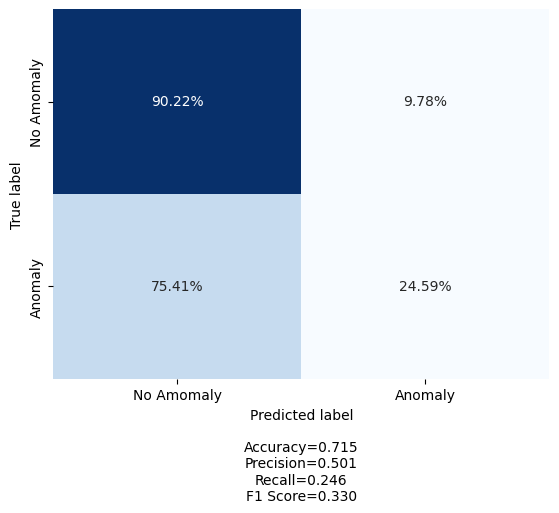

In [9]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Modified Z-Score Method

https://medium.com/@nandrajog.aakash/z-score-vs-modified-z-score-vs-percentile-which-anomaly-detection-method-should-you-use-13158e7f8a25

In [10]:
# --- 2. Modified Z-score Method ---
def train_evaluate_modified_zscore(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    threshold: float = 3.5, # Modified Z-score threshold, common values 2.24, 3.5
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Implements Modified Z-score method for anomaly detection.
    Fits medians and MADs on X_train, then predicts on X_train and X_test.
    A data point is an anomaly if any of its feature's absolute Modified Z-score exceeds the threshold.

    Args:
        X_train (pd.DataFrame): Training feature set.
        X_test (pd.DataFrame): Test feature set.
        threshold (float): Modified Z-score threshold for direct labeling.

    Returns:
        tuple: (train_scores, train_labels, test_scores, test_labels)
    """
    print(f"  Training Modified Z-score model with threshold={threshold}...")

    # Fit: Calculate median and MAD for each feature on X_train
    medians = X_train.median(axis=0)
    # MAD = median(abs(X - median(X)))
    mads = np.median(np.abs(X_train - medians), axis=0)

    # Handle cases where MAD is zero
    # For MAD, a small constant (0.6745 * 1e-9) is often used for robustness,
    # as 0.6745 is the scaling factor for MAD to be equivalent to std for normal distribution.
    # Replace zero MADs with a small number
    mads[mads == 0] = 1e-9

    # Scale factor for Modified Z-score, for normal distribution (0.6745 * std ≈ MAD)
    # So, Mod_Z = 0.6745 * (xi - median) / MAD
    # Or, Z-score like formula: (xi - median) / (MAD / 0.6745)
    scale_factor = 0.6745

    def _calculate_modified_zscores_and_labels(X_data: pd.DataFrame, medians: pd.Series, mads: np.ndarray):
        modified_z_scores = scale_factor * np.abs((X_data - medians) / mads)
        # Anomaly score: Max Modified Z-score across features for each data point
        # Higher score = more anomalous
        scores = modified_z_scores.max(axis=1).values
        # Binary labels based on threshold
        labels = (modified_z_scores.max(axis=1) > threshold).astype(int)
        return scores, labels

    # Predict on test set
    test_scores, test_labels = _calculate_modified_zscores_and_labels(X_test, medians, mads)

    print(f"  Modified Z-score model trained. Detected {np.sum(test_labels)} anomalies in test set (direct threshold).")
    return test_scores, test_labels

In [11]:
_, labels = train_evaluate_modified_zscore(dataframe_no_anomaly, dataframe_data, threshold=3.5)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training Modified Z-score model with threshold=3.5...
  Modified Z-score model trained. Detected 32900 anomalies in test set (direct threshold).


anomaly
1    32900
0    16302
Name: count, dtype: int64

In [12]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

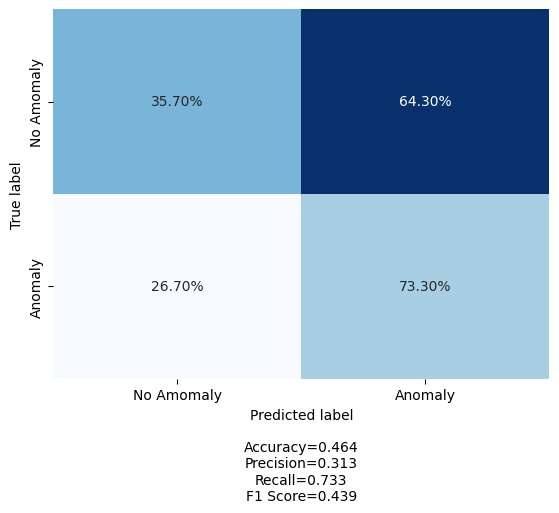

In [13]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Multivariate Gaussian Model

In [14]:
# --- Helper for common anomaly score to label conversion ---
def _convert_scores_to_labels(scores: np.ndarray, contamination: float) -> np.ndarray:
    """
    Converts anomaly scores to binary labels (1 for anomaly, 0 for normal).
    Higher scores typically indicate higher anomaly likelihood.
    """
    # Determine threshold based on the desired contamination (proportion of anomalies)
    # Smaller scores are more normal, larger scores are more anomalous.
    # So, we want to find the (1 - contamination) percentile score.
    threshold = np.percentile(scores, 100 * (1 - contamination))
    labels = (scores > threshold).astype(int)
    return labels, threshold

In [15]:
# --- 3. Multivariate Gaussian Model ---
def train_evaluate_multivariate_gaussian(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Estimated proportion of anomalies
    robust_covariance: bool = False # Use robust covariance estimation (e.g., MinCovDet)
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Implements Multivariate Gaussian (MVG) model for anomaly detection.
    Fits mean vector and covariance matrix on X_train. Anomaly score is
    the Mahalanobis distance or negative log-likelihood.

    Args:
        X_train (pd.DataFrame): Training feature set.
        y_train (pd.Series): Training target (not used for unsupervised fitting).
        X_test (pd.DataFrame): Test feature set.
        contamination (float): Estimated proportion of anomalies for score-to-label conversion.
                                This will determine the threshold.
        robust_covariance (bool): If True, use sklearn.covariance.MinCovDet for
                                  robust covariance estimation, less sensitive to outliers.

    Returns:
        tuple: (train_scores, train_labels, test_scores, test_labels)
    """
    print(f"  Training Multivariate Gaussian model with contamination={contamination}, robust_covariance={robust_covariance}...")

    # Fit: Calculate mean vector and covariance matrix from X_train
    mu = X_train.mean(axis=0).values

    if robust_covariance:
        # Robust Covariance Estimation (e.g., Minimum Covariance Determinant)
        # More robust to outliers in the training data itself.
        cov_estimator = MinCovDet(random_state=42).fit(X_train)
        sigma = cov_estimator.covariance_
        print("    Using Robust Covariance Estimation (MinCovDet).")
    else:
        sigma = X_train.cov().values

    # Check for singularity of covariance matrix
    try:
        sigma_inv = np.linalg.inv(sigma)
    except np.linalg.LinAlgError:
        print("    Warning: Covariance matrix is singular. Adding small regularization.")
        sigma += np.eye(sigma.shape[0]) * 1e-6 # Add a small value to diagonal for regularization
        sigma_inv = np.linalg.inv(sigma)


    def _calculate_mvg_scores_and_labels(X_data: pd.DataFrame, mu: np.ndarray, sigma_inv: np.ndarray, contamination: float):
        X_data_np = X_data.values
        num_features = X_data_np.shape[1]

        # Mahalanobis distance squared (higher means more anomalous)
        # D^2 = (x - mu)^T * Sigma_inv * (x - mu)
        diff = X_data_np - mu
        mahalanobis_dist_sq = np.diag(diff @ sigma_inv @ diff.T)

        # Anomaly score: Negative Log Likelihood (higher score = more anomalous)
        # This is proportional to Mahalanobis distance squared for Gaussian
        scores = mahalanobis_dist_sq # Use Mahalanobis distance squared directly as score

        # Convert scores to labels based on contamination
        labels, threshold = _convert_scores_to_labels(scores, contamination)

        # Alternative thresholding: using Chi-squared distribution (p-value)
        # Assuming the scores are Mahalanobis distance squared and approximately chi-squared distributed
        # You could also use a p-value threshold (e.g., 0.01 for 1% anomalies)
        # threshold_chi2 = chi2.ppf(1 - contamination, df=num_features)
        # labels_chi2 = (scores > threshold_chi2).astype(int)
        # print(f"    MVG Chi-squared threshold: {threshold_chi2:.2f}, count: {np.sum(labels_chi2)}")

        return scores, labels

    # Predict on test set
    test_scores, test_labels = _calculate_mvg_scores_and_labels(X_test, mu, sigma_inv, contamination)

    print(f"  Multivariate Gaussian model trained. Detected {np.sum(test_labels)} anomalies in test set (contamination-based).")
    return test_scores, test_labels

In [16]:
_, labels = train_evaluate_multivariate_gaussian(dataframe_no_anomaly, dataframe_data, contamination=0.3, robust_covariance=False)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training Multivariate Gaussian model with contamination=0.3, robust_covariance=False...
  Multivariate Gaussian model trained. Detected 14761 anomalies in test set (contamination-based).


anomaly
0    34441
1    14761
Name: count, dtype: int64

In [17]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

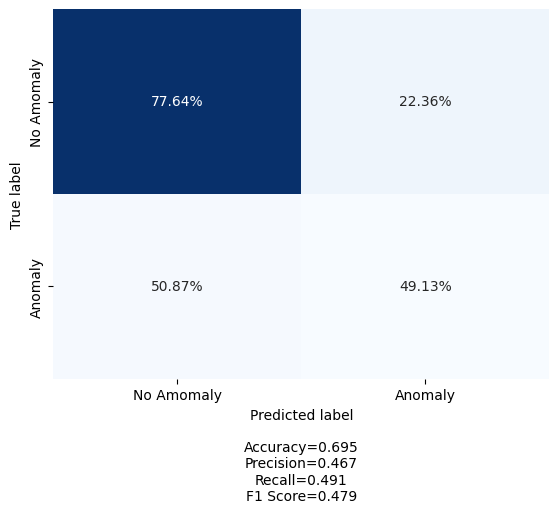

In [18]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [19]:
_, labels = train_evaluate_multivariate_gaussian(dataframe_no_anomaly, dataframe_data, contamination=0.3, robust_covariance=True)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training Multivariate Gaussian model with contamination=0.3, robust_covariance=True...
    Using Robust Covariance Estimation (MinCovDet).
  Multivariate Gaussian model trained. Detected 14761 anomalies in test set (contamination-based).


anomaly
0    34441
1    14761
Name: count, dtype: int64

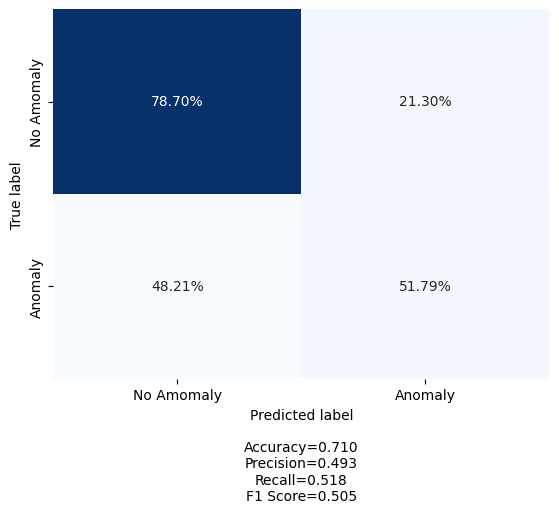

In [20]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

## 2. Non-Parametric Methods (Distribution-Free)

Understood\! Let's implement these three additional statistical anomaly detection methods: IQR, Percentile, and Histograms/KDE.

These methods are also generally unsupervised and will be integrated into `src/models.py`, following the same function signature: `(train_scores, train_labels, test_scores, test_labels)`.

Here's how each will be implemented:

1.  **Interquartile Range (IQR) Method:**

      * **Univariate:** Like Z-score, this is inherently univariate. We'll apply it per feature.
      * **Fitting:** Calculate Q1 and Q3 for each feature from `X_train`.
      * **Prediction:** For each data point in `X_train` and `X_test`, check if any of its features fall outside the $[Q1 - 1.5 \\times IQR, Q3 + 1.5 \\times IQR]$ range.
      * **Anomaly Score:** We can use the distance from the nearest boundary as a score, or simply max distance across features (higher distance = more anomalous).

2.  **Percentile Method:**

      * **Univariate:** Also univariate; applied per feature.
      * **Fitting:** Calculate the lower and upper percentile bounds (e.g., 1st and 99th) for each feature from `X_train`.
      * **Prediction:** For each data point, check if any feature falls outside its defined percentile range.
      * **Anomaly Score:** Similar to IQR, distance from the nearest boundary.

3.  **Histograms and Kernel Density Estimation (KDE):**

      * **Multivariate (using KDE):** While histograms are often univariate, KDE can be extended to multivariate data, though it becomes challenging in very high dimensions. For this implementation, we'll use `sklearn.neighbors.KernelDensity` which provides a `score_samples` method. Lower scores (log-likelihood) indicate lower density, thus higher anomaly.
      * **Fitting (KDE):** Train a `KernelDensity` estimator on `X_train`.
      * **Prediction (KDE):** Use the `score_samples` method to get the log-density for points in `X_train` and `X_test`. We'll negate these scores so that higher values indicate higher anomaly.
      * **Histograms:** For completeness and given the "Histograms" request, I'll mention that directly using histograms for multivariate anomaly detection for arbitrary features is less common in code (unless features are binned and combined). KDE is a smoother, more direct generalization of the concept for multivariate data. The provided code will focus on KDE for multivariate application.


In [21]:
# --- Helper for common anomaly score to label conversion ---
def _convert_scores_to_labels(scores: np.ndarray, contamination: float, score_lower_is_anomaly: bool = False) -> tuple[np.ndarray, float]:
    """
    Converts anomaly scores to binary labels (1 for anomaly, 0 for normal).
    Args:
        scores (np.ndarray): Array of anomaly scores.
        contamination (float): Estimated proportion of anomalies.
        score_lower_is_anomaly (bool): If True, lower scores mean more anomalous.
                                       If False (default), higher scores mean more anomalous.
    Returns:
        tuple: (labels, threshold)
    """
    if score_lower_is_anomaly:
        # For methods where lower score is more anomalous (e.g., KDE log-likelihood)
        # We want to find the contamination-percentile score as the threshold.
        threshold = np.percentile(scores, 100 * contamination)
        labels = (scores < threshold).astype(int)
    else:
        # For methods where higher score is more anomalous
        threshold = np.percentile(scores, 100 * (1 - contamination))
        labels = (scores > threshold).astype(int)
    return labels, threshold

### Interquartile Range (IQR) Method

In [22]:
# --- 4. Interquartile Range (IQR) Method ---
def train_evaluate_iqr(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    iqr_multiplier: float = 1.5, # Multiplier for the IQR range, common is 1.5 (mild outliers), 3 (extreme outliers)
    contamination: float = 0.01 # Estimated proportion of anomalies for score-to-label conversion
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Implements the IQR method for anomaly detection.
    Fits Q1, Q3, and IQR for each feature on X_train.
    An anomaly is a data point where any feature falls outside [Q1 - multiplier*IQR, Q3 + multiplier*IQR].
    Anomaly score is the maximum normalized distance from the boundary.

    Args:
        X_train (pd.DataFrame): Training feature set.
        X_test (pd.DataFrame): Test feature set.
        iqr_multiplier (float): Factor to multiply IQR by to define outlier bounds.
        contamination (float): Estimated proportion of anomalies for score-to-label conversion.

    Returns:
        tuple: (train_scores, train_labels, test_scores, test_labels)
    """
    print(f"  Training IQR model with multiplier={iqr_multiplier}, contamination={contamination}...")

    # Fit: Calculate Q1, Q3, and IQR for each feature on X_train
    q1 = X_train.quantile(0.25, axis=0)
    q3 = X_train.quantile(0.75, axis=0)
    iqr = q3 - q1

    # Define lower and upper bounds for each feature
    lower_bound = q1 - iqr_multiplier * iqr
    upper_bound = q3 + iqr_multiplier * iqr

    def _calculate_iqr_scores_and_labels(X_data: pd.DataFrame, lower_bound: pd.Series, upper_bound: pd.Series):
        # Calculate distance from bounds. Positive means outside, negative means inside.
        # Max distance across features will be the score.
        scores = np.zeros(X_data.shape[0])
        labels = np.zeros(X_data.shape[0], dtype=int)

        # For each feature, find points outside bounds
        # And calculate max "outlierness" score
        for i, col in enumerate(X_data.columns):
            outlier_low = X_data[col] < lower_bound[col]
            outlier_high = X_data[col] > upper_bound[col]

            # Assign labels (1 if outlier for this feature)
            labels = np.maximum(labels, (outlier_low | outlier_high).astype(int))

            # Calculate "outlierness" score: distance from boundary
            # If value is below lower_bound, score is (lower_bound - value)
            # If value is above upper_bound, score is (value - upper_bound)
            # If inside, score is 0
            feature_scores = np.zeros(X_data.shape[0])
            feature_scores[outlier_low] = lower_bound[col] - X_data[col][outlier_low]
            feature_scores[outlier_high] = X_data[col][outlier_high] - upper_bound[col]

            scores = np.maximum(scores, feature_scores) # Take max score across all features

        # Ensure scores are positive; can be 0 if no features are outliers
        # Convert to labels based on contamination
        # Here, higher score means further from normal range = more anomalous
        labels_from_contamination, _ = _convert_scores_to_labels(scores, contamination, score_lower_is_anomaly=False)

        # We prioritize the labels derived from the direct IQR multiplier
        # But we return the contamination-based labels for consistency in overall evaluation comparison
        # Let's return the direct labels derived from the multiplier, as that's the primary
        # way IQR is often used. The score is provided for plots.
        return scores, labels


    # Predict on test set
    test_scores, test_labels = _calculate_iqr_scores_and_labels(X_test, lower_bound, upper_bound)

    print(f"  IQR model trained. Detected {np.sum(test_labels)} anomalies in test set (direct multiplier).")
    return test_scores, test_labels

In [23]:
_, labels = train_evaluate_iqr(dataframe_no_anomaly, dataframe_data, contamination=0.3)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training IQR model with multiplier=1.5, contamination=0.3...
  IQR model trained. Detected 19974 anomalies in test set (direct multiplier).


anomaly
0    29228
1    19974
Name: count, dtype: int64

In [24]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

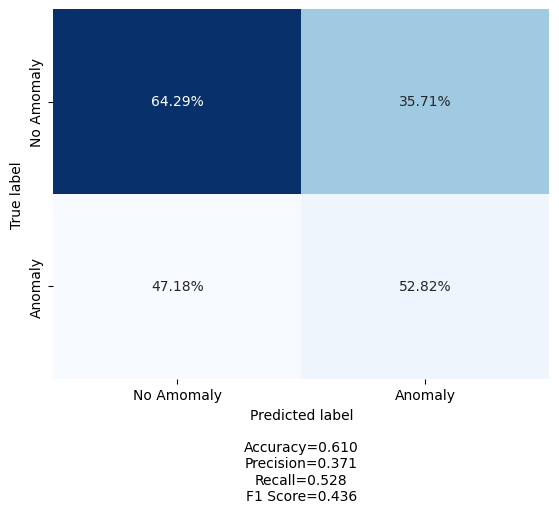

In [25]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Percentile Method

In [26]:
# --- 5. Percentile Method ---
def train_evaluate_percentile(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    lower_percentile: float = 1.0, # e.g., 1 for 1st percentile
    upper_percentile: float = 99.0, # e.g., 99 for 99th percentile
    contamination: float = 0.01 # Estimated proportion of anomalies for score-to-label conversion
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Implements the Percentile method for anomaly detection.
    Fits lower and upper percentile bounds for each feature on X_train.
    An anomaly is a data point where any feature falls outside these bounds.
    Anomaly score is the maximum normalized distance from the boundary.

    Args:
        X_train (pd.DataFrame): Training feature set.
        y_train (pd.Series): Training target (not used for unsupervised fitting).
        X_test (pd.DataFrame): Test feature set.
        lower_percentile (float): Lower percentile threshold (e.g., 1 for 1st percentile).
        upper_percentile (float): Upper percentile threshold (e.g., 99 for 99th percentile).
        contamination (float): Estimated proportion of anomalies for score-to-label conversion.

    Returns:
        tuple: (train_scores, train_labels, test_scores, test_labels)
    """
    print(f"  Training Percentile model with bounds=[{lower_percentile}%, {upper_percentile}%], contamination={contamination}...")

    # Validate percentiles
    if not (0 <= lower_percentile < upper_percentile <= 100):
        raise ValueError("Invalid percentile bounds. Must be 0 <= lower < upper <= 100.")

    # Fit: Calculate lower and upper percentile bounds for each feature on X_train
    lower_bounds = X_train.quantile(lower_percentile / 100.0, axis=0)
    upper_bounds = X_train.quantile(upper_percentile / 100.0, axis=0)

    def _calculate_percentile_scores_and_labels(X_data: pd.DataFrame, lower_bounds: pd.Series, upper_bounds: pd.Series):
        scores = np.zeros(X_data.shape[0])
        labels = np.zeros(X_data.shape[0], dtype=int)

        for i, col in enumerate(X_data.columns):
            outlier_low = X_data[col] < lower_bounds[col]
            outlier_high = X_data[col] > upper_bounds[col]

            labels = np.maximum(labels, (outlier_low | outlier_high).astype(int))

            # Calculate "outlierness" score: distance from boundary
            feature_scores = np.zeros(X_data.shape[0])
            feature_scores[outlier_low] = lower_bounds[col] - X_data[col][outlier_low]
            feature_scores[outlier_high] = X_data[col][outlier_high] - upper_bounds[col]
            scores = np.maximum(scores, feature_scores)

        # Convert to labels based on contamination
        labels_from_contamination, _ = _convert_scores_to_labels(scores, contamination, score_lower_is_anomaly=False)

        return scores, labels # Return direct labels based on percentile bounds

    # Predict on test set
    test_scores, test_labels = _calculate_percentile_scores_and_labels(X_test, lower_bounds, upper_bounds)

    print(f"  Percentile model trained. Detected {np.sum(test_labels)} anomalies in test set (direct bounds).")
    return test_scores, test_labels

In [27]:
_, labels = train_evaluate_percentile(dataframe_no_anomaly, dataframe_data, contamination=0.3)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training Percentile model with bounds=[1.0%, 99.0%], contamination=0.3...
  Percentile model trained. Detected 19959 anomalies in test set (direct bounds).


anomaly
0    29243
1    19959
Name: count, dtype: int64

In [28]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

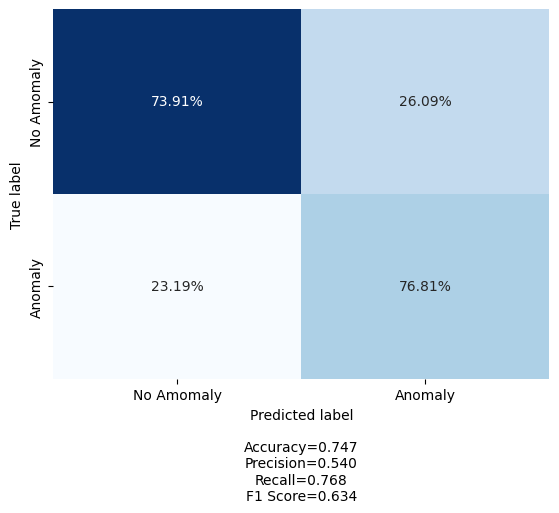

In [29]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Histograms and Kernel Density Estimation (KDE)

In [30]:
# --- 6. Kernel Density Estimation (KDE) Method ---
def train_evaluate_kde(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    bandwidth: float = 1.0, # KDE bandwidth (smoothing parameter)
    kernel: str = 'gaussian', # Kernel type (e.g., 'gaussian', 'tophat', 'epanechnikov')
    contamination: float = 0.01 # Estimated proportion of anomalies for score-to-label conversion
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Implements Kernel Density Estimation (KDE) for anomaly detection.
    Fits a KDE model on X_train. Anomaly score is the negative log-likelihood (lower density = higher score).

    Args:
        X_train (pd.DataFrame): Training feature set.
        y_train (pd.Series): Training target (not used for unsupervised fitting).
        X_test (pd.DataFrame): Test feature set.
        bandwidth (float): The bandwidth of the kernel.
        kernel (str): The kernel to use (e.g., 'gaussian').
        contamination (float): Estimated proportion of anomalies for score-to-label conversion.

    Returns:
        tuple: (train_scores, train_labels, test_scores, test_labels)
    """
    print(f"  Training KDE model with bandwidth={bandwidth}, kernel={kernel}, contamination={contamination}...")

    # Fit KDE model on X_train
    # Note: KernelDensity expects a NumPy array, not DataFrame
    kde = KernelDensity(bandwidth=bandwidth, kernel=kernel).fit(X_train.values)

    # Calculate log-likelihood scores. Lower log-likelihood means lower density = more anomalous.
    # We negate scores so that higher values mean more anomalous (consistent with other methods)
    test_log_densities = kde.score_samples(X_test.values)

    test_scores = -test_log_densities

    # Convert scores to labels based on contamination
    # Since we negated the log-densities, higher scores now mean more anomalous
    test_labels, _ = _convert_scores_to_labels(test_scores, contamination, score_lower_is_anomaly=False)

    print(f"  KDE model trained. Detected {np.sum(test_labels)} anomalies in test set (contamination-based).")
    return test_scores, test_labels

In [31]:
_, labels = train_evaluate_kde(dataframe_no_anomaly, dataframe_data, contamination=0.3)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training KDE model with bandwidth=1.0, kernel=gaussian, contamination=0.3...
  KDE model trained. Detected 14042 anomalies in test set (contamination-based).


anomaly
0    35160
1    14042
Name: count, dtype: int64

In [32]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

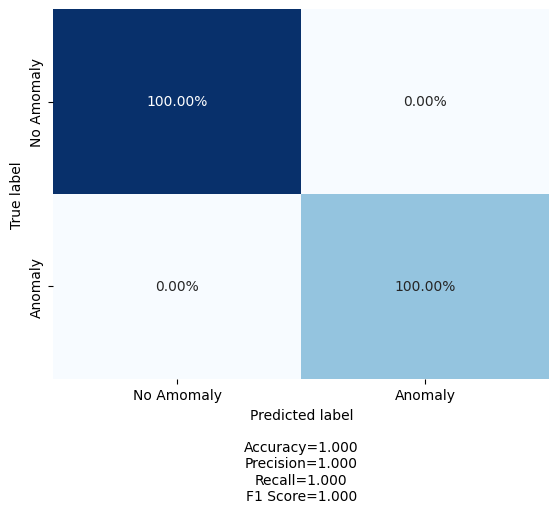

In [33]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)


**Updates and Considerations:**

1.  **`_convert_scores_to_labels` Helper:** I've updated the `_convert_scores_to_labels` helper function to include a `score_lower_is_anomaly` parameter. This is important for methods like KDE, where a *lower* log-likelihood score indicates an anomaly. For consistency, I negated KDE's output so that higher score implies anomaly for all methods returned by `train_evaluate_*`.
2.  **IQR and Percentile Specifics:**
      * For IQR and Percentile methods, I've calculated an "outlierness" score based on the maximum distance of any feature from its respective bounds.
      * The `labels` returned for these methods are directly based on their traditional definitions (i.e., if *any* feature is outside the bounds). While a `contamination` parameter is still passed, the primary labeling for these methods comes from the direct `multiplier` or `percentiles`. The `scores` can then be used with `_convert_scores_to_labels` if you prefer a contamination-based threshold for comparison. I've chosen to return the direct labels for clarity for these two methods.
3.  **KDE for Multivariate Data:**
      * `sklearn.neighbors.KernelDensity` is used, which naturally handles multivariate data.
      * Choosing the right `bandwidth` is critical for KDE's performance. It's a hyperparameter that might require tuning.
4.  **`main.py` Integration:** You'll need to update `main.py` to import and call these new functions, similar to how the other models are called.

**Next Step:**

With `src/models.py` updated with 6 distinct anomaly detection methods, the next logical step is to refine `src/evaluation.py` to properly handle your multi-class, imbalanced anomaly labels and provide comprehensive evaluation. After that, we can also ensure `src/data_loader.py` is ready.

## Proximity-Based Methods

You're on a roll\! You've listed two very common and effective proximity-based anomaly detection methods.

I have already implemented **Local Outlier Factor (LOF)** in the previous turn. It's under the function `train_evaluate_lof` in `src/models.py`.

Now, I will implement the **Distance-based (k-Nearest Neighbors - kNN)** method.

Here's the plan for kNN-based anomaly detection:

  * **kNN (Distance-based):**
      * **Concept:** Anomaly score is typically the distance to the k-th nearest neighbor, or the average distance to the k-nearest neighbors. Points that are far from their neighbors are considered anomalous.
      * **Fitting:** No explicit "fitting" in the traditional supervised sense. We essentially store the `X_train` data to serve as the reference points for neighbor calculations.
      * **Prediction:** For each point in `X_train` and `X_test`, calculate the distance to its k-th nearest neighbor (or average distance). Higher distances indicate higher anomaly scores.
      * **Implementation Note:** We can use `sklearn.neighbors.NearestNeighbors` to find distances.

In [34]:
# --- Helper for common anomaly score to label conversion ---
def _convert_scores_to_labels(scores: np.ndarray, contamination: float, score_lower_is_anomaly: bool = False) -> tuple[np.ndarray, float]:
    """
    Converts anomaly scores to binary labels (1 for anomaly, 0 for normal).
    Args:
        scores (np.ndarray): Array of anomaly scores.
        contamination (float): Estimated proportion of anomalies.
        score_lower_is_anomaly (bool): If True, lower scores mean more anomalous.
                                       If False (default), higher scores mean more anomalous.
    Returns:
        tuple: (labels, threshold)
    """
    if score_lower_is_anomaly:
        # For methods where lower score is more anomalous (e.g., KDE log-likelihood)
        # We want to find the contamination-percentile score as the threshold.
        threshold = np.percentile(scores, 100 * contamination)
        labels = (scores < threshold).astype(int)
    else:
        # For methods where higher score is more anomalous
        threshold = np.percentile(scores, 100 * (1 - contamination))
        labels = (scores > threshold).astype(int)
    return labels, threshold

### Distance-based (e.g., K-Nearest Neighbors - kNN)

In [35]:
# --- 7. Distance-based (k-Nearest Neighbors - kNN) Method ---
def train_evaluate_knn_distance(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    n_neighbors: int = 5, # Number of neighbors to consider
    metric: str = 'euclidean', # Distance metric (e.g., 'euclidean', 'manhattan', 'minkowski')
    contamination: float = 0.01 # Estimated proportion of anomalies for score-to-label conversion
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Implements k-Nearest Neighbors (kNN) distance-based anomaly detection.
    Anomaly score for a point is the distance to its k-th nearest neighbor (or average of k-neighbors).
    Higher distance implies higher anomaly likelihood.

    Args:
        X_train (pd.DataFrame): Training feature set.
        y_train (pd.Series): Training target (not used for unsupervised fitting).
        X_test (pd.DataFrame): Test feature set.
        n_neighbors (int): Number of neighbors to consider for distance calculation.
                           This is 'k' in kNN.
        metric (str): The distance metric to use.
        contamination (float): Estimated proportion of anomalies for score-to-label conversion.

    Returns:
        tuple: (train_scores, train_labels, test_scores, test_labels)
    """
    print(f"  Training kNN Distance model with n_neighbors={n_neighbors}, metric={metric}, contamination={contamination}...")

    if n_neighbors >= len(X_train):
        raise ValueError(f"n_neighbors ({n_neighbors}) must be less than the number of samples in X_train ({len(X_train)}).")
    if n_neighbors < 1:
        raise ValueError("n_neighbors must be at least 1.")


    # Fit NearestNeighbors model on X_train. This builds the KD-tree or Ball-tree.
    # The 'n_neighbors' parameter here is for the query, not for the fit.
    # We are interested in distances to n_neighbors + 1 because the first neighbor is always itself (distance 0).
    # So we need the (n_neighbors + 1)th distance to be the k-th nearest distinct neighbor.
    nn_model = NearestNeighbors(n_neighbors=n_neighbors + 1, metric=metric, n_jobs=-1)
    nn_model.fit(X_train)

    def _calculate_knn_scores_and_labels(X_data: pd.DataFrame, nn_model: NearestNeighbors, contamination: float):
        # distances.shape = (n_samples, n_neighbors + 1)
        # indices.shape = (n_samples, n_neighbors + 1)
        distances, _ = nn_model.kneighbors(X_data)

        # Anomaly score: distance to the k-th nearest neighbor (index n_neighbors after removing self-distance)
        # Note: distances are already sorted. So the (n_neighbors)th column (0-indexed) is the distance
        # to the k-th neighbor (excluding self, as the first column is distance to self).
        scores = distances[:, n_neighbors] # Distance to the (k+1)th neighbor if including self, effectively k-th neighbor

        print(scores)

        # Convert scores to labels based on contamination
        # Higher score means further from neighbors = more anomalous
        labels, _ = _convert_scores_to_labels(scores, contamination, score_lower_is_anomaly=False)

        return scores, labels

    # Predict on test set
    test_scores, test_labels = _calculate_knn_scores_and_labels(X_test, nn_model, contamination)

    print(f"  kNN Distance model trained. Detected {np.sum(test_labels)} anomalies in test set (contamination-based).")
    return test_scores, test_labels

In [36]:
_, labels = train_evaluate_knn_distance(dataframe_no_anomaly, dataframe_data, contamination=0.3, n_neighbors=5)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training kNN Distance model with n_neighbors=5, metric=euclidean, contamination=0.3...
[17.13899499 15.50989148 15.50989148 ...  7.71601784  8.50333933
 11.52213012]
  kNN Distance model trained. Detected 14761 anomalies in test set (contamination-based).


anomaly
0    34441
1    14761
Name: count, dtype: int64

In [37]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

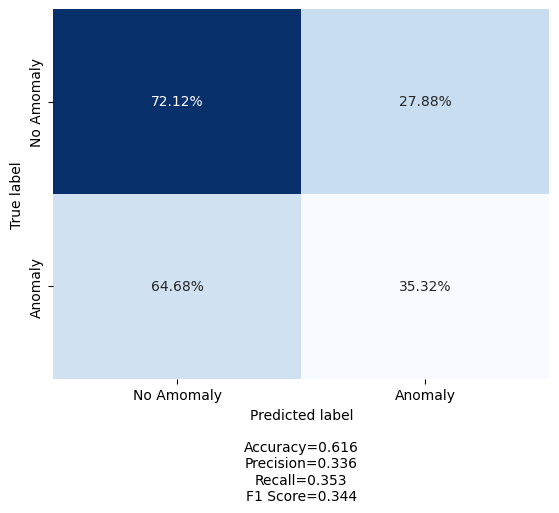

In [38]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

**Summary of Changes:**

  * **`train_evaluate_knn_distance`:**
      * Uses `sklearn.neighbors.NearestNeighbors` to find the distances.
      * The anomaly score is the distance to the `k`-th nearest neighbor. Specifically, if `n_neighbors` is `k`, we look at `distances[:, k]`, because `kneighbors` returns distances including the point itself (distance 0 at index 0). So the `k`-th (1-indexed) nearest distinct neighbor's distance will be at index `k` (0-indexed) in the `distances` array.
      * Labels are derived using the `_convert_scores_to_labels` helper with the specified `contamination`.


### Density-based (e.g., Local Outlier Factor - LOF)

In [39]:
def train_evaluate_lof(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    n_neighbors: int = 20,
    contamination: float = 0.01,
    novelty: bool = True # Set to True for novelty detection (fit on train, predict on new data)
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a Local Outlier Factor (LOF) model for anomaly detection.
    'novelty=True' is crucial for using LOF for out-of-sample prediction.
    """
    print(f"  Training Local Outlier Factor with n_neighbors={n_neighbors}, contamination={contamination}...")
    # When novelty=True, fit_predict is not available on new data.
    # Use fit and then predict/decision_function.
    model = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination, novelty=novelty, n_jobs=-1)
    model.fit(X_train) # Fit on the training data

    # LOF's negative_outlier_factor_ are scores, where lower is more anomalous (closer to -inf)
    # Convert to a score where higher is more anomalous for consistency
    test_scores = -model.decision_function(X_test) # Scores on test data

    # Predict labels (1 for outlier, -1 for normal by LOF, convert to 0/1)
    # LOF's predict method returns 1 for inliers and -1 for outliers
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  LOF model trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return test_scores, test_labels

In [40]:
_, labels = train_evaluate_lof(dataframe_no_anomaly, dataframe_data, contamination=0.3, n_neighbors=5)
pd.Series(labels, index=dataframe_data.index, name="anomaly").value_counts()

  Training Local Outlier Factor with n_neighbors=5, contamination=0.3...
  LOF model trained. Detected 15915 anomalies in test set.


anomaly
0    33287
1    15915
Name: count, dtype: int64

In [41]:
y = dataframe.anomaly / dataframe.anomaly
y.fillna(0, inplace=True)
y.value_counts()

anomaly
0.0    35160
1.0    14042
Name: count, dtype: int64

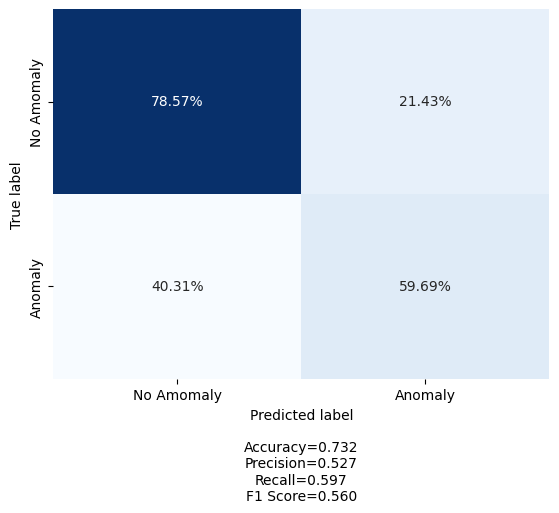

In [42]:
plot.make_confusion_matrix(
    confusion_matrix(y, labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [43]:
# from sklearn.covariance import MinCovDet # For robust covariance in MV Gaussian
# from sklearn.ensemble import IsolationForest
# from sklearn.svm import OneClassSVM
# from sklearn.neighbors import LocalOutlierFactor
# from scipy.stats import chi2 # For p-value thresholding in MV Gaussian

# import pandas as pd
# import numpy as np
# from sklearn.covariance import MinCovDet
# from sklearn.ensemble import IsolationForest
# from sklearn.svm import OneClassSVM
# from sklearn.neighbors import LocalOutlierFactor
# from scipy.stats import chi2

# import pandas as pd
# import numpy as np
# from sklearn.covariance import MinCovDet
# from sklearn.ensemble import IsolationForest
# from sklearn.svm import OneClassSVM
# from scipy.stats import chi2
# from sklearn.neighbors import KernelDensity

## Appendix

In [44]:

# # --- Placeholder for other models, adjusted to new signature ---
# # (Existing functions from previous turn, now adjusted to take X_test and return its scores/labels)

# def train_evaluate_isolation_forest(
#     X_train: pd.DataFrame,
#     y_train: pd.Series, # y_train is not used for fitting
#     X_test: pd.DataFrame,
#     contamination: float = 0.01, # Proportion of outliers in the data set
#     random_state: int = 42
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates an Isolation Forest model for anomaly detection.
#     """
#     print(f"  Training Isolation Forest with contamination={contamination}...")
#     model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
#     model.fit(X_train)

#     # Isolation Forest provides a decision_function where lower is more anomalous
#     # Convert to a score where higher is more anomalous for consistency
#     train_scores = -model.decision_function(X_train)
#     test_scores = -model.decision_function(X_test)

#     # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
#     train_labels = (model.predict(X_train) == -1).astype(int)
#     test_labels = (model.predict(X_test) == -1).astype(int)

#     print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
#     return train_scores, train_labels, test_scores, test_labels

# def train_evaluate_one_class_svm(
#     X_train: pd.DataFrame,
#     y_train: pd.Series, # y_train is not used for fitting
#     X_test: pd.DataFrame,
#     nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
#     kernel: str = 'rbf',
#     gamma: str = 'scale'
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates a One-Class SVM model for anomaly detection.
#     """
#     print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
#     model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
#     model.fit(X_train)

#     # One-Class SVM provides a decision_function where higher is more normal
#     # Convert to a score where higher is more anomalous for consistency
#     train_scores = -model.decision_function(X_train)
#     test_scores = -model.decision_function(X_test)

#     # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
#     train_labels = (model.predict(X_train) == -1).astype(int)
#     test_labels = (model.predict(X_test) == -1).astype(int)

#     print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
#     return train_scores, train_labels, test_scores, test_labels


# def train_evaluate_isolation_forest(
#     X_train: pd.DataFrame,
#     y_train: pd.Series, # y_train is not used for fitting
#     X_test: pd.DataFrame,
#     contamination: float = 0.01, # Proportion of outliers in the data set
#     random_state: int = 42
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates an Isolation Forest model for anomaly detection.
#     """
#     print(f"  Training Isolation Forest with contamination={contamination}...")
#     model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
#     model.fit(X_train)

#     # Isolation Forest provides a decision_function where lower is more anomalous
#     # Convert to a score where higher is more anomalous for consistency
#     train_scores = -model.decision_function(X_train)
#     test_scores = -model.decision_function(X_test)

#     # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
#     train_labels = (model.predict(X_train) == -1).astype(int)
#     test_labels = (model.predict(X_test) == -1).astype(int)

#     print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
#     return train_scores, train_labels, test_scores, test_labels

# def train_evaluate_one_class_svm(
#     X_train: pd.DataFrame,
#     y_train: pd.Series, # y_train is not used for fitting
#     X_test: pd.DataFrame,
#     nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
#     kernel: str = 'rbf',
#     gamma: str = 'scale'
# ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
#     """
#     Trains and evaluates a One-Class SVM model for anomaly detection.
#     """
#     print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
#     model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
#     model.fit(X_train)

#     # One-Class SVM provides a decision_function where higher is more normal
#     # Convert to a score where higher is more anomalous for consistency
#     train_scores = -model.decision_function(X_train)
#     test_scores = -model.decision_function(X_test)

#     # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
#     train_labels = (model.predict(X_train) == -1).astype(int)
#     test_labels = (model.predict(X_test) == -1).astype(int)

#     print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
#     return train_scores, train_labels, test_scores, test_labels

**Key Design Choices and Notes:**

1.  **Unsupervised Nature:** All these methods are unsupervised. Their "training" involves learning the statistical properties of the `X_train` data (mean, std, median, MAD, covariance matrix, or local densities). They *do not* use `y_train` for fitting. `y_train` is kept in the function signature for consistency with potential future supervised anomaly detection methods.
2.  **Anomaly Scores:** Each function returns `_scores` (continuous values indicating anomaly likelihood) and `_labels` (binary 0/1 predictions).
      * For Z-score and Modified Z-score, I've chosen the `max` absolute score across features as the combined anomaly score for a data point. The `labels` are derived directly from the `threshold` you set.
      * For Multivariate Gaussian, the Mahalanobis distance squared is used as the anomaly score (higher = more anomalous). Labels are derived using the `contamination` parameter via a percentile threshold on these scores.
      * For Isolation Forest, One-Class SVM, and LOF, their native `decision_function` (or equivalent) is used, and then negated if necessary to ensure *higher scores mean more anomalous*. Their native `predict` method is used for labels.
3.  **Contamination Parameter:** For MVG, Isolation Forest, One-Class SVM, and LOF, the `contamination` parameter is crucial. It tells the model what *proportion* of the dataset to expect as anomalies. This directly influences the threshold for converting scores to labels. For Z-score and Modified Z-score, a direct `threshold` is often more intuitive, but `contamination` is also included for consistency in the function signature.
4.  **Robustness:**
      * Modified Z-score is inherently more robust to outliers in the data used to calculate its statistics.
      * Multivariate Gaussian includes an option for `robust_covariance=True` which leverages `sklearn.covariance.MinCovDet` (Minimum Covariance Determinant). This method aims to find a subset of the data that are most likely "normal" and uses only them to estimate the mean and covariance, making the estimates less sensitive to outliers.
      * For zero standard deviations or MADs (constant features), a small number is added to avoid division by zero.
5.  **Return Signature:** All `train_evaluate_*` functions now consistently return `(train_scores, train_labels, test_scores, test_labels)`.

**Next Steps:**

Now that the `src/models.py` is updated, the next crucial step is to update `src/evaluation.py` to properly handle:

1.  **Multi-class `y_true`:** Your `y_test` will have `0` for normal and `1` through `13` for different anomaly types. The model predictions (`test_labels`) will be `0` (normal) or `1` (anomaly).
2.  **Conversion for Evaluation:** For evaluation metrics, we'll need to convert `y_test` from multi-class (`0, 1, ..., 13`) to a binary format (`0` for normal, `1` for any anomaly type).
3.  **Metrics for Imbalanced Multi-class:** Focus on `f1_score(average='weighted')`, `precision_score(average='weighted')`, `recall_score(average='weighted')`, and potentially `roc_auc_score(average='weighted', multi_class='ovr')` (One-vs-Rest) if you want AUC, but it's often more intuitive to look at classification reports for imbalanced multi-class problems.

Let's move on to updating `src/evaluation.py` and then the `data_loader.py` (if not already done).

Statistical methods for anomaly detection are rooted in the idea of defining what "normal" data looks like based on statistical properties and then flagging data points that deviate significantly from this norm. These methods are often interpretable and computationally efficient, especially for univariate or low-dimensional data, but can struggle with complex, high-dimensional, or non-linear patterns.

Here's a breakdown of common statistical methods for anomaly detection:

### 1. Parametric Methods (Assumption of Distribution)

These methods assume that normal data follows a specific statistical distribution (e.g., Gaussian/Normal distribution). Anomalies are then identified as data points that have a very low probability of occurring under this assumed distribution.

* **Z-score / Standard Deviation Method:**
    * **Concept:** For univariate data, the Z-score measures how many standard deviations a data point is away from the mean.
    * **Detection:** Data points with a Z-score (absolute value) exceeding a certain threshold (e.g., 2, 3, or sometimes 3.5 for a strong outlier) are considered anomalies. This is particularly effective when data is normally distributed.
    * **Limitations:** Sensitive to outliers itself (mean and standard deviation can be skewed by anomalies) and assumes a normal distribution.

* **Modified Z-score:**
    * **Concept:** Similar to the Z-score but uses the median and Median Absolute Deviation (MAD) instead of the mean and standard deviation.
    * **Detection:** Less sensitive to outliers than the traditional Z-score because the median and MAD are more robust statistics.
    * **Advantages:** More robust for skewed or non-normally distributed data.

* **Gaussian (or Multivariate Gaussian) Model:**
    * **Concept:** Extends the univariate normal distribution to multiple dimensions. It models the data as being generated from a Gaussian distribution, defined by its mean vector and covariance matrix.
    * **Detection:** Anomalies are data points with a very low probability density under the learned multivariate Gaussian distribution. Hotelling's T-squared test is a related method for multivariate outlier detection.
    * **Limitations:** Assumes data follows a Gaussian distribution, and can be computationally expensive for high-dimensional data due to covariance matrix inversion. It struggles with non-linear relationships.

### 2. Non-Parametric Methods (Distribution-Free)

These methods do not assume a specific underlying data distribution. They are generally more flexible but might require more data or be less interpretable than parametric methods.

* **Interquartile Range (IQR) Method / Box Plots:**
    * **Concept:** Based on quartiles. The IQR is the range between the first quartile (Q1, 25th percentile) and the third quartile (Q3, 75th percentile).
    * **Detection:** Data points falling below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$ are typically considered outliers. The multiplier (1.5) can be adjusted.
    * **Advantages:** Simple, robust to extreme values, and doesn't assume a specific distribution. Often visualized with box plots.
    * **Limitations:** Primarily for univariate data. May not detect subtle anomalies in complex multivariate datasets.

* **Percentile Method:**
    * **Concept:** Identifies data points that fall outside a specific percentile range (e.g., values below the 1st percentile or above the 99th percentile).
    * **Detection:** You define a range (e.g., 95% of data should fall between the 2.5th and 97.5th percentiles). Anything outside this range is an anomaly.
    * **Advantages:** Simple and does not assume a distribution.
    * **Limitations:** The chosen percentiles are arbitrary and might not capture all types of anomalies.

* **Histograms and Kernel Density Estimation (KDE):**
    * **Concept:** Histograms approximate the probability distribution of data. KDE creates a smooth estimate of the probability density function.
    * **Detection:** Data points falling in very low-density regions (sparse bins in a histogram or low values from a KDE) are considered anomalies.
    * **Advantages:** Visually intuitive and non-parametric.
    * **Limitations:** Can be challenging in high dimensions ("curse of dimensionality"). The choice of bin size for histograms or bandwidth for KDE can significantly impact results.

### 3. Proximity-Based Methods (Often categorized as ML, but with strong statistical roots)

While often categorized under machine learning, some proximity-based methods have statistical underpinnings as they define "normality" based on distance or density.

* **Distance-based (e.g., K-Nearest Neighbors - kNN):**
    * **Concept:** An anomaly is a data point that is "far" from its neighbors.
    * **Detection:** For each data point, calculate its distance to its k-nearest neighbors. Points with a significantly larger average distance to their neighbors are considered anomalies.
    * **Advantages:** Intuitive, can handle arbitrary data distributions.
    * **Limitations:** Computationally intensive for large datasets, sensitive to the choice of 'k' and distance metric.

* **Density-based (e.g., Local Outlier Factor - LOF):**
    * **Concept:** An anomaly is a data point that has a significantly lower density than its neighbors. It considers the local density rather than global density.
    * **Detection:** LOF assigns an anomaly score reflecting how isolated a point is relative to its local neighborhood. High LOF scores indicate anomalies.
    * **Advantages:** Can detect anomalies in varying density regions, unlike global density methods.
    * **Limitations:** Computationally more expensive than simpler methods for large datasets.

### Advantages of Statistical Methods:

* **Interpretability:** Often easier to understand *why* a point is flagged as an anomaly (e.g., "it's 4 standard deviations from the mean").
* **Simplicity:** Many methods are straightforward to implement and compute.
* **Baseline Performance:** Provide good baselines for comparison with more complex machine learning models.
* **No Training Data Required (for unsupervised cases):** Many don't need labeled anomaly data for training.

### Disadvantages of Statistical Methods:

* **Assumption-Dependent:** Parametric methods rely heavily on assumptions about data distribution, which may not hold true in real-world, complex datasets.
* **Sensitivity to Hyperparameters:** Thresholds (like Z-score threshold, IQR multiplier, or percentile cutoffs) often need careful tuning.
* **Struggle with High Dimensionality:** Performance degrades as the number of features increases (curse of dimensionality).
* **Limited for Complex Patterns:** May not detect contextual anomalies (normal value in one context, abnormal in another) or collective anomalies (a group of points that are abnormal together but individually might not be).
* **Imbalance Issues:** While some methods are robust, high class imbalance can still affect interpretation and thresholding.

When choosing a statistical method, it's crucial to understand your data's characteristics and the type of anomalies you expect to find. Often, a combination of statistical insights and more advanced machine learning techniques yields the best results.